# Variational Quantum Algorithms (VQE)

Author: Vanessa Knight

## Objective

This notebook introduces **Variational Quantum Algorithms (VQAs)**, with a focus on the **Variational Quantum Eigensolver (VQE)**.

Unlike previous algorithms, which follow a fixed sequence of quantum gates, VQE uses a **parameterized quantum circuit** whose parameters are optimized by a classical computer.

This hybrid quantum-classical approach is one of the leading applications of today's noisy quantum computers.

## Topics Covered

- Hybrid Quantum-Classical Computing
- Parameterized Quantum Circuits
- Rotation Gates
- Ansatz
- Cost Function
- Classical Optimizer
- Variational Quantum Eigensolver (VQE)

## Learning Goals

By the end of this notebook, I should be able to:

- Explain why VQE is a hybrid algorithm.
- Build a parameterized quantum circuit.
- Understand the role of an Ansatz.
- Explain how classical optimization updates quantum parameters.
- Understand why VQE is important for current quantum hardware.

> VQE is one of the most widely studied algorithms for today's NISQ (Noisy Intermediate-Scale Quantum) computers because it can tolerate more noise than many large fault-tolerant algorithms.

# 1. Why Variational Algorithms?

Many famous quantum algorithms, such as Shor's Algorithm, require large fault-tolerant quantum computers.

Today's quantum computers are much smaller and much noisier.

Instead of executing one large quantum algorithm,

Variational Quantum Algorithms combine:

- a quantum computer
- a classical computer

working together.

The quantum computer prepares quantum states.

The classical computer evaluates the results and updates the circuit parameters.

This process repeats until a good solution is found.

This hybrid approach makes VQE practical on today's quantum hardware.

## Hybrid Quantum-Classical Loop

A VQE algorithm repeatedly performs the following steps:

```text
Choose Parameters

↓

Build Quantum Circuit

↓

Execute Quantum Circuit

↓

Measure Results

↓

Compute Cost Function

↓

Classical Optimizer Updates Parameters

↓

Repeat
```

Each iteration gradually improves the quantum circuit until the cost function reaches a minimum.

Unlike Grover or QFT, VQE is **not** a fixed sequence of gates.

Instead, it learns the best circuit through optimization.

# 2. Parameterized Quantum Circuits

Unlike the fixed circuits used in Grover's Algorithm or the Quantum Fourier Transform, a variational circuit contains **parameters** that can be adjusted.

Instead of writing

```python
qc.ry(pi/2, 0)
```

we write

```python
qc.ry(theta, 0)
```

where `theta` is a variable.

During optimization, a classical computer repeatedly changes these parameters until the quantum circuit produces the best possible result.

These adjustable parameters make the circuit **trainable**.

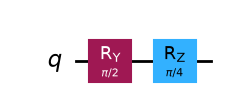

In [1]:
from math import pi
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)

theta = pi / 2
phi = pi / 4

# Parameterized rotations
qc.ry(theta, 0)
qc.rz(phi, 0)

qc.draw("mpl")

## Understanding the Circuit

This circuit contains two rotation gates.

```python
qc.ry(theta, 0)
```

rotates the qubit about the **Y-axis** by an angle

$$
\theta
$$

and

```python
qc.rz(phi, 0)
```

rotates the qubit about the **Z-axis** by an angle

$$
\phi.
$$

Earlier we used fixed values such as

```python
pi/2
```

or

```python
pi/4
```

In VQE, these angles become **variables** that are automatically adjusted by a classical optimizer.

### Notes

The important idea is **not** the specific values of `theta` and `phi`.

The important idea is that they can change.

For example,

Iteration 1

```text
theta = 0.8
phi = 0.3
```

↓

Iteration 2

```text
theta = 1.2
phi = 0.6
```

↓

Iteration 3

```text
theta = 1.57
phi = 0.79
```

Each time the parameters change, a new quantum state is prepared.

The optimizer keeps adjusting the parameters until the cost function is minimized.

# 3. The Ansatz

An **Ansatz** is a parameterized quantum circuit designed to generate a family of possible quantum states.

Instead of building one fixed circuit, we build a flexible circuit whose parameters can be adjusted.

The optimizer then searches for the parameter values that produce the best solution.

Think of the Ansatz as the **model** that the optimizer is training.

A simple Ansatz might contain only a few rotation gates.

More advanced Ansätze may contain dozens or even hundreds of parameterized gates.

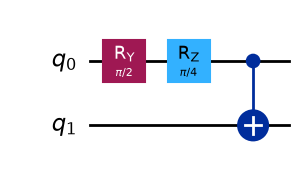

In [2]:
from math import pi
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

theta = pi / 2
phi = pi / 4

# Parameterized Ansatz
qc.ry(theta, 0)
qc.rz(phi, 0)

# Create entanglement
qc.cx(0, 1)

qc.draw("mpl")

## Understanding the Ansatz

This Ansatz consists of three parts.

### 1. Prepare a Quantum State

```python
qc.ry(theta,0)
```

The parameter `theta` determines the rotation of qubit 0.

### 2. Apply Another Parameter

```python
qc.rz(phi,0)
```

The parameter `phi` changes the phase of the quantum state.

### 3. Entangle the Qubits

```python
qc.cx(0,1)
```

The CNOT gate allows information to be shared between both qubits.

Without entanglement, the Ansatz would be much less expressive.

The optimizer will repeatedly adjust `theta` and `phi` while keeping the circuit structure unchanged.

### Why Is an Ansatz Important?

The optimizer **does not invent new quantum circuits.**

Instead, it adjusts the parameters inside the existing Ansatz.

Think of it like fitting a curve to data.

The shape of the curve is fixed.

Only the parameters change.

Likewise,

- the Ansatz defines the circuit structure,
- the optimizer learns the best parameter values.

A well-designed Ansatz is one of the most important factors in building an effective VQE algorithm.

# 4. The Cost Function

A **cost function** is a numerical score that tells us how well the current quantum circuit is performing.

After each execution of the quantum circuit,

1. The circuit is measured.
2. A numerical value is computed.
3. The classical optimizer decides how to change the parameters.

The objective is simple:

- Minimize the cost function.

The lower the cost, the better the current quantum state.

## Intuition

Think of climbing down a mountain.

At the top:

```text
High Cost ❌
```

↓

The optimizer adjusts the parameters.

↓

The circuit is executed again.

↓

A new cost is calculated.

↓

Eventually the optimizer reaches

```text
Low Cost ✅
```

The optimizer is trying to find the **lowest point** in the landscape.

# 5. The Classical Optimizer

The optimizer is a **classical algorithm**.

It does **not** modify the quantum circuit itself.

Instead, it changes only the circuit parameters.

For example,

Iteration 1

```text
θ = 0.5
φ = 0.3
Cost = 1.82
```

↓

Iteration 2

```text
θ = 1.0
φ = 0.6
Cost = 0.91
```

↓

Iteration 3

```text
θ = 1.57
φ = 0.79
Cost = 0.12
```

As the parameters improve, the cost decreases.

Eventually, the optimizer stops when no better parameters can be found.

## The Complete VQE Loop

Putting everything together, the algorithm works as follows:

```text
Choose Initial Parameters

↓

Build the Ansatz

↓

Run the Quantum Circuit

↓

Measure the Circuit

↓

Compute the Cost Function

↓

Classical Optimizer Updates Parameters

↓

Repeat Until Convergence
```

Notice that the **quantum computer never learns**.

The **classical optimizer** is responsible for learning the best parameters.

The quantum computer simply prepares and measures quantum states.

### Why Is VQE Practical?

Large algorithms such as Shor's Algorithm require thousands or even millions of reliable qubits.

Today's quantum computers are much smaller and much noisier.

VQE works well on today's hardware because:

- It uses relatively short circuits.
- The optimizer can compensate for some hardware imperfections.
- The quantum computer only performs the parts that are difficult to simulate classically.

For this reason, VQE is one of the most important algorithms in the NISQ (Noisy Intermediate-Scale Quantum) era.

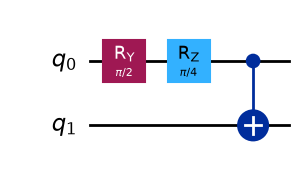

In [3]:
from math import pi
from qiskit import QuantumCircuit

# Simple VQE-style Ansatz
qc = QuantumCircuit(2)

theta = pi / 2
phi = pi / 4

# Parameterized rotations
qc.ry(theta, 0)
qc.rz(phi, 0)

# Entangle the qubits
qc.cx(0, 1)

qc.draw("mpl")

# 6. Analyzing the Circuit

Although this is a simple example, it already contains the three main ingredients of a Variational Quantum Eigensolver.

## Parameterized Gates

```python
qc.ry(theta,0)
qc.rz(phi,0)
```

These gates prepare a quantum state whose shape depends on the parameters.

The optimizer will repeatedly adjust these parameters during training.

## Entanglement

```python
qc.cx(0,1)
```

The CNOT gate creates entanglement between the two qubits.

Entanglement allows the Ansatz to represent much richer quantum states than independent qubits alone.

## Trainable Circuit

Unlike previous algorithms,

- the circuit structure remains fixed,
- only the parameter values change.

This is why VQE is called a **variational** algorithm.

In [4]:
print("Qubits :", qc.num_qubits)
print("Depth  :", qc.depth())
print("Size   :", qc.size())
print("Operations:")
print(qc.count_ops())

Qubits : 2
Depth  : 3
Size   : 3
Operations:
OrderedDict({'ry': 1, 'rz': 1, 'cx': 1})


# 7. Resource Analysis

Just like Grover's Algorithm and the Quantum Fourier Transform, we can evaluate a VQE circuit using engineering metrics.

Important metrics include:

- Number of qubits
- Circuit depth
- Circuit size
- Gate counts

For this simple Ansatz you should observe:

- **2 qubits**
- A very shallow circuit depth
- Two single-qubit rotation gates
- One CNOT gate

One reason VQE performs well on today's hardware is that its circuits are often much shallower than algorithms such as Shor's Algorithm.

Shallow circuits accumulate less noise, making them more practical on current quantum devices.

### Notes

One of the biggest insights while learning VQE is realizing that nothing "magical" happens inside the quantum computer.

The quantum computer simply:

- prepares a quantum state,
- measures it,
- returns the result.

The classical optimizer is responsible for improving the parameters.

Together, the quantum computer and the classical optimizer gradually search for better solutions.

This collaboration is what makes VQE a **hybrid quantum-classical algorithm**.

# Notebook Summary

Congratulations! You have completed the Variational Quantum Eigensolver (VQE) notebook.

## Concepts Learned

✅ Hybrid Quantum-Classical Computing

✅ Parameterized Quantum Circuits

✅ Rotation Gates

✅ Ansatz

✅ Cost Function

✅ Classical Optimizer

✅ Variational Quantum Eigensolver (VQE)

✅ Resource Analysis

## Key Ideas

- VQE is a **hybrid algorithm**.
- The quantum computer prepares and measures quantum states.
- The classical optimizer updates the circuit parameters.
- The Ansatz defines the family of quantum states that can be explored.
- The optimizer minimizes a cost function by repeatedly adjusting the parameters.
- VQE is one of the most practical algorithms for today's NISQ quantum computers.

## Looking Ahead

The next notebook introduces **Shor's Algorithm**.

Unlike VQE, Shor's Algorithm is a fault-tolerant algorithm designed to factor large integers efficiently using:

- Quantum Fourier Transform
- Period Finding
- Modular Arithmetic

Shor's Algorithm demonstrates one of the most dramatic known quantum speedups.

# 🎯 Interview Corner

### What is a Variational Quantum Algorithm?

A Variational Quantum Algorithm is a hybrid quantum-classical algorithm that optimizes the parameters of a quantum circuit using a classical optimizer.

### What is an Ansatz?

An Ansatz is a parameterized quantum circuit that defines the family of quantum states the optimizer can explore.

### What is the role of the optimizer?

The optimizer updates the circuit parameters to minimize the cost function.

### Why is VQE important?

VQE works well on today's noisy quantum hardware because it uses relatively shallow circuits and combines the strengths of both quantum and classical computing.

### Does the quantum computer perform the optimization?

No.

The quantum computer only prepares and measures quantum states.

The classical optimizer performs the optimization.

# Quick Self-Review

Try answering these questions without looking back.

1. What is a Variational Quantum Algorithm?

2. Why is VQE called a hybrid algorithm?

3. What is an Ansatz?

4. Why are rotation gates parameterized?

5. What is the purpose of the cost function?

6. What does the classical optimizer do?

7. Why is entanglement included in many Ansätze?

8. Why is VQE well suited for NISQ hardware?

9. What engineering metrics can be used to evaluate a VQE circuit?

10. Which component actually "learns" during optimization?

# Key Takeaways

- VQE combines quantum circuits with classical optimization.
- Parameterized rotation gates create trainable quantum circuits.
- The Ansatz determines which quantum states can be explored.
- The cost function measures how well the current parameters perform.
- The classical optimizer improves the parameters over many iterations.
- VQE is one of the most practical quantum algorithms for current quantum hardware.

Understanding VQE provides a strong foundation for modern quantum software development and quantum machine learning.